In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules

In [2]:
df_movies = pd.read_csv('dados/movies.csv') # lê os arquivos da base de dados
df_ratings = pd.read_csv('dados/ratings.csv')

In [3]:
df_ratings.dropna(subset=['movieId', 'userId'], inplace=True) # limpeza: retira os dados que tem chaves nulas

In [4]:
df_movie_stats = df_ratings.groupby('movieId').agg( # transformação de dados por agregação
    nota_media=('rating', 'mean'), # agrega notas e contagem de votos por filme
    total_votos=('rating', 'count')
).reset_index()

In [5]:
df_clustering_base = pd.merge(df_movies, df_movie_stats, on='movieId', how='inner') # cruza tabelas trazendo os títulos e gêneros dos filmes

In [6]:
df_clustering_base = df_clustering_base[df_clustering_base['total_votos'] >= 5].reset_index(drop=True) # filtro para manter apenas filmes com 5 ou mais votos (redução de ruído)
                                                                                                       # filtro com 1 (ou poucas notas) gera uma nota injusta pela média

In [7]:
scaler = StandardScaler() # padronização z-score
X_scaled = scaler.fit_transform(df_clustering_base[['nota_media', 'total_votos']])

print(f'Pré-processamento concluído. \nTotal de filmes filtrados para o K-Means: {df_clustering_base.shape[0]}')


Pré-processamento concluído. 
Total de filmes filtrados para o K-Means: 43873


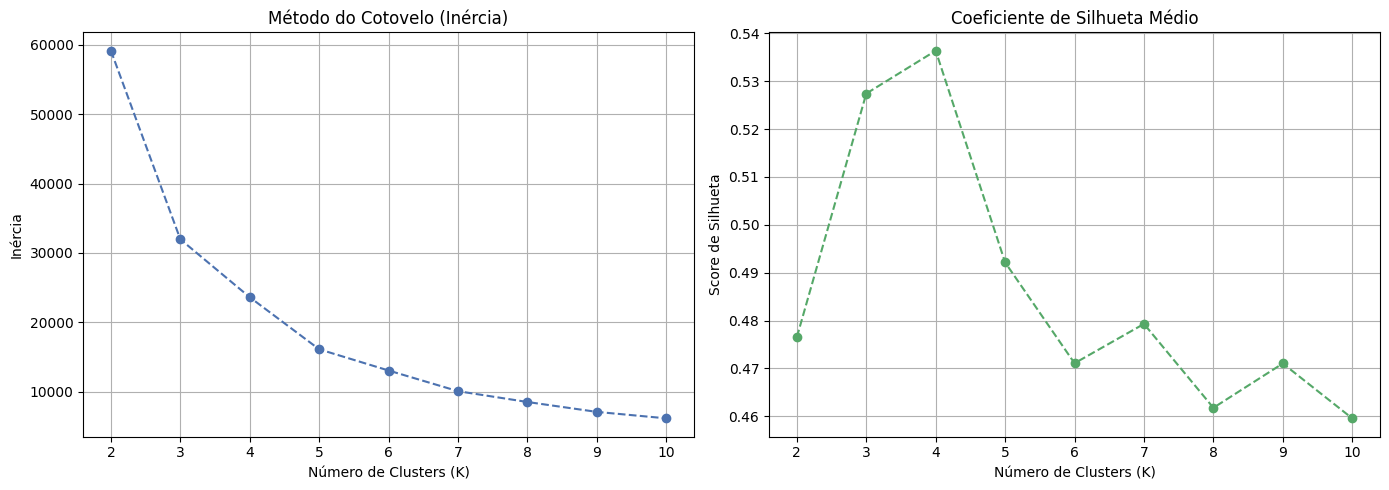

Valores numéricos de Silhueta por K:
K = 2: Silhueta = 0.477
K = 3: Silhueta = 0.527
K = 4: Silhueta = 0.536
K = 5: Silhueta = 0.492
K = 6: Silhueta = 0.471
K = 7: Silhueta = 0.479
K = 8: Silhueta = 0.462
K = 9: Silhueta = 0.471
K = 10: Silhueta = 0.460


In [8]:
wcss = []
valores_silhueta = []
K_lista = range(2, 11) # silhueta exige no mínimo 2 clusters para comparar as distâncias

for i in K_lista: # calcular as métricas de validação de clusters (testa os valores de k)
    kmeans = KMeans(n_clusters=i, n_init=10, max_iter=300, random_state=42) # configuração kmeans
    labels = kmeans.fit_predict(X_scaled)
    
    wcss.append(kmeans.inertia_) # coletando inércia para método do cotovelo
    
    score = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42) # calcula coeficiente de silhueta
    valores_silhueta.append(score)


fig, ax = plt.subplots(1, 2, figsize=(14, 5)) # configuração e plotagem dos gráficos

ax[0].plot(list(K_lista), wcss, marker='o', linestyle='--', color='#4C72B0') # gráfico esquerda - método do cotovelo
ax[0].set_title('Método do Cotovelo (Inércia)')
ax[0].set_xlabel('Número de Clusters (K)')
ax[0].set_ylabel('Inércia')
ax[0].grid(True)

ax[1].plot(list(K_lista), valores_silhueta, marker='o', linestyle='--', color='#55A868') # gráfico direita - coeficiente de silhueta
ax[1].set_title('Coeficiente de Silhueta Médio')
ax[1].set_xlabel('Número de Clusters (K)')
ax[1].set_ylabel('Score de Silhueta')
ax[1].grid(True)

plt.tight_layout()
plt.show()

print('Valores numéricos de Silhueta por K:') # exibe valores númericos para relatório
for i, s in enumerate(valores_silhueta):
    k = K_lista[i] # busca o valor de K correspondente àquela posição
    print(f'K = {k}: Silhueta = {s:.3f}')

In [9]:
k_escolhido = 3 # número ideal de grupos baseado no melhor score de silhueta obtido k=3

modelo = KMeans(n_clusters=k_escolhido, n_init=10, max_iter=300, random_state=42) # inicializa e roda algoritmo definitivo com dados padronizados
df_clustering_base['cluster'] = modelo.fit_predict(X_scaled)

centroids = scaler.inverse_transform(modelo.cluster_centers_) # desfaz escala z-score dos centróides para analisar os valores reais de notas e votos

df_centroids = pd.DataFrame(centroids, columns=['Nota Média Centroid', 'Total Votos Centroid']) # cria um dataarame para exibir as características centrais de cada grupo

print(f'Perfil Técnico dos Grupos (Centróides) \n{df_centroids}')

Perfil Técnico dos Grupos (Centróides) 
   Nota Média Centroid  Total Votos Centroid
0             3.423397            567.208187
1             2.522639            207.247417
2             3.681085          28613.596117


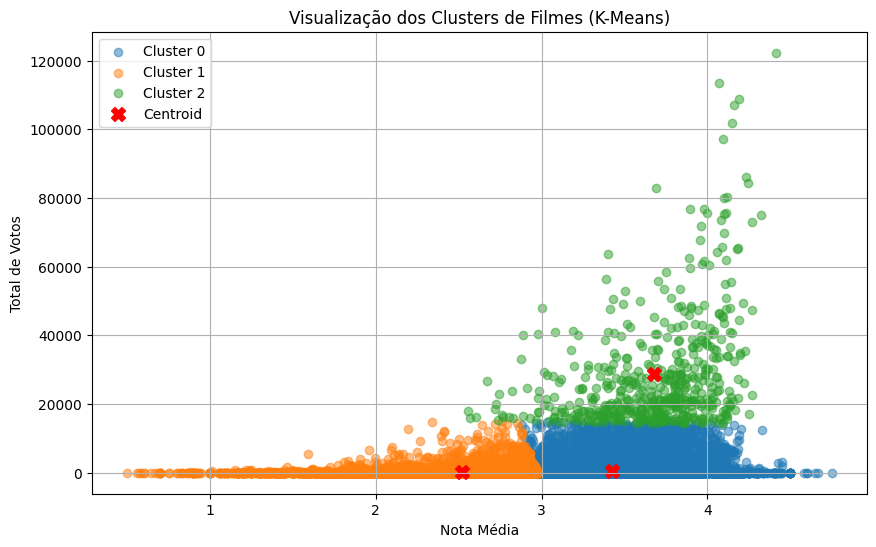

Amostra real de filmes por Cluster

Filmes que o K-Means agrupou no Cluster 0:
Tom and Huck (1995)
Sudden Death (1995)
       Balto (1995)
       Nixon (1995)
  Four Rooms (1995)

Filmes que o K-Means agrupou no Cluster 1:
          Waiting to Exhale (1995)
Dracula: Dead and Loving It (1995)
           Cutthroat Island (1995)
                Money Train (1995)
     Across the Sea of Time (1995)

Filmes que o K-Means agrupou no Cluster 2:
                  Toy Story (1995)
                    Jumanji (1995)
           Grumpier Old Men (1995)
Father of the Bride Part II (1995)
                       Heat (1995)


In [10]:
plt.figure(figsize=(10, 6)) # configura tamanho da figura

for i in range(k_escolhido): # laço para separar e colorir cada um dos 3 grupos
    sub_grupo = df_clustering_base[df_clustering_base['cluster'] == i]
    plt.scatter(sub_grupo['nota_media'], sub_grupo['total_votos'], label=f'Cluster {i}', alpha=0.5) # plota pontos na tela: nota média (eixo x) e total de votos (eixo y)

plt.scatter(centroids[:, 0], centroids[:, 1], s=100, c='red', marker='X', label='Centroid') # insere os centróides calculados (x verm)

plt.title('Visualização dos Clusters de Filmes (K-Means)') # elementos textuais do gráfico (título e rótulos dos eixos)
plt.xlabel('Nota Média')
plt.ylabel('Total de Votos')
plt.legend()
plt.grid(True)
plt.show()

print('Amostra real de filmes por Cluster') # amostragem de filmes para análise crítica da conclusão
for i in range(k_escolhido):
    print(f'\nFilmes que o K-Means agrupou no Cluster {i}:')
    print(df_clustering_base[df_clustering_base['cluster'] == i]['title'].head(5).to_string(index=False)) # head(5), mostra apenas os 5 primeiros filmes de cada grupo

In [11]:
df_likes = df_ratings[df_ratings['rating'] >= 4.0] # filtro de seleção: considera apenas avaliações >= 4 (reduz linhas)
                                                   # garante analise de filmes que usuário realmente gostou (relevância de mercado)
                                                   # associação por título

top_filmes = df_likes['movieId'].value_counts().head(200).index # redução de dados e dimensionalidade 
                                                                # identifica 200 filmes mais curtidos para evitar estouro de memória (reduz colunas)

df_likes_filtrado = df_likes[df_likes['movieId'].isin(top_filmes)] # filtra base de dados, mantendo apenas curtidas que pertencentes aos 200 filmes

df_regras_base = pd.merge(df_likes_filtrado, df_movies[['movieId', 'title']], on='movieId') # integração: cruza com a tabela de filmes para obter os títulos em texto

matriz_transacoes = (df_regras_base # pivotagem de dados: transforma linhas de avaliações em uma matriz de "cesta de compras" (comportamento dos usuários)
                     .groupby(['userId', 'title'])['title'] # linhas viram usuários (userid) e colunas viram ítulos dos filmes (title)
                     .count().unstack().reset_index().fillna(0)
                     .set_index('userId'))

matriz_apriori = matriz_transacoes > 0

print(f'Dimensões da matriz (Usuários x Filmes): {matriz_apriori.shape}')

Dimensões da matriz (Usuários x Filmes): (283514, 200)


In [12]:
frequent_itemsets = apriori(matriz_apriori, min_support=0.15, use_colnames=True) # execução do apriori
                                                                                 # min_support definido em 0.15 (filmes precisam aparecer em pelo menos 15% das cestas)

regras = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.50) # geração das regras de associação, utilizando métrica de confiança
                                                                                       # min_threshold definido em 0.50 (mínimo de 50% de confiança na regra)

print(f'Total de regras por título encontradas: {len(regras)}')

Total de regras por título encontradas: 20


In [13]:
regras_ordenadas = regras.sort_values(by='confidence', ascending=False) # seleção e apresentação dos resultados
                                                                                 # ordena regras por confiança e elevação (lift) para exibir no relatório

print('Principais associações por título encontradas:')

for idx, row in regras_ordenadas.head(20).iterrows(): # formata a visualização para mostrar antecedentes -> consequentes e as métricas
    antecedente = ', '.join(list(row['antecedents']))
    consequente = ', '.join(list(row['consequents']))
    print(f'SE ({antecedente}) → ENTÃO ({consequente})')
    print(f'Suporte: {row['support']:.3f} - Confiança: {row['confidence']:.3f} - Lift: {row['lift']:.3f}\n')

Principais associações por título encontradas:
SE (Lord of the Rings: The Two Towers, The (2002)) → ENTÃO (Lord of the Rings: The Fellowship of the Ring, The (2001))
Suporte: 0.166 - Confiança: 0.862 - Lift: 4.081

SE (Lord of the Rings: The Two Towers, The (2002)) → ENTÃO (Lord of the Rings: The Return of the King, The (2003))
Suporte: 0.162 - Confiança: 0.838 - Lift: 4.198

SE (Lord of the Rings: The Return of the King, The (2003)) → ENTÃO (Lord of the Rings: The Fellowship of the Ring, The (2001))
Suporte: 0.167 - Confiança: 0.835 - Lift: 3.953

SE (Lord of the Rings: The Return of the King, The (2003)) → ENTÃO (Lord of the Rings: The Two Towers, The (2002))
Suporte: 0.162 - Confiança: 0.810 - Lift: 4.198

SE (Star Wars: Episode V - The Empire Strikes Back (1980)) → ENTÃO (Star Wars: Episode IV - A New Hope (1977))
Suporte: 0.175 - Confiança: 0.809 - Lift: 3.153

SE (Star Wars: Episode VI - Return of the Jedi (1983)) → ENTÃO (Star Wars: Episode IV - A New Hope (1977))
Suporte: 0.152

In [14]:
df_likes = df_ratings[df_ratings['rating'] >= 4.0] # filtro de seleção: considera apenas avaliações ótimas >= 4
                                                   # associação por gênero

df_usuario_generos = pd.merge(df_likes[['userId', 'movieId']], df_movies[['movieId', 'genres']], on='movieId') # integração: traz apenas coluna gêneros dos filmes

df_gosto_usuario = df_usuario_generos.groupby('userId')['genres'].apply(lambda x: '|'.join(x)).reset_index() # agrupa por usuário e lista gêneros únicos
                                                                                                             # reduz volume de dados antes de criar matriz
df_gosto_usuario['genres'] = df_gosto_usuario['genres'].apply(lambda x: list(set(x.split('|')))) # transforma string única de gêneros acumulados do usuário em lista

df_gosto_explodido = df_gosto_usuario.explode('genres') # explode a lista (com poucas linhas por usuário) - impede travamento

df_gosto_explodido = df_gosto_explodido[df_gosto_explodido['genres'] != '(no genres listed)'] # limpeza: remove termos genéricos como (no genres listed)

matriz_usuario_generos = (df_gosto_explodido # pivotagem: cria matriz binária (cada linha um usuário, cada coluna um gênero)
                          .groupby(['userId', 'genres'])['genres']
                          .count().unstack().reset_index().fillna(0)
                          .set_index('userId'))

matriz_apriori_usuario_generos = matriz_usuario_generos > 0

print(f'Dimensões da matriz (Usuários x Gêneros): {matriz_apriori_usuario_generos.shape}')

Dimensões da matriz (Usuários x Gêneros): (324391, 19)


In [15]:
frequent_user_genres = apriori(matriz_apriori_usuario_generos, min_support=0.60, use_colnames=True) # apriori com suporte mínimo de 0.60 (60%) devido alta frequência de gêneros

regras_user_generos = association_rules(frequent_user_genres, metric='confidence', min_threshold=0.60) # gera regras utilizando a métrica confiança mínima de 60%

regras_user_generos_ordenadas = regras_user_generos.sort_values(by='confidence', ascending=False) # ordena resultados pelas regras mais impactantes

print(f'Total de regras por gêneros encontradas: {len(regras_user_generos_ordenadas)}')

Total de regras por gêneros encontradas: 5372


In [16]:
regras_puras = regras_user_generos_ordenadas[ # filtro: mantém apenas regras onde antecedente e consequente possuem apenas 1 item
                                              # elimina regras gigantescas e poluídas (ex: se gosta de A, B, C... -> gosta de E)
    (regras_user_generos_ordenadas['antecedents'].apply(len) == 1) & 
    (regras_user_generos_ordenadas['consequents'].apply(len) == 1)
]

# garante que o fift seja maior que 1 (regras com associação positiva real)
regras_puras = regras_puras[regras_puras['lift'] > 1.0]

print(f'Total de regras com 1 gênero encontradas: {len(regras_puras)}')
print('\nTop 10 regras de gênero por usuário')

for idx, row in regras_puras.head(10).iterrows(): # exibe 10 melhores regras
    antecedente = ', '.join(list(row['antecedents']))
    consequente = ', '.join(list(row['consequents']))
    print(f'SE ({antecedente}) → ENTÃO ({consequente})')
    print(f'Suporte: {row['support']:.3f} - Confiança: {row['confidence']:.3f} - Lift: {row['lift']:.3f}\n')

Total de regras com 1 gênero encontradas: 94

Top 10 regras de gênero por usuário
SE (War) → ENTÃO (Drama)
Suporte: 0.637 - Confiança: 0.998 - Lift: 1.045

SE (Mystery) → ENTÃO (Drama)
Suporte: 0.662 - Confiança: 0.990 - Lift: 1.037

SE (Crime) → ENTÃO (Drama)
Suporte: 0.813 - Confiança: 0.987 - Lift: 1.034

SE (Romance) → ENTÃO (Drama)
Suporte: 0.806 - Confiança: 0.985 - Lift: 1.032

SE (Mystery) → ENTÃO (Thriller)
Suporte: 0.656 - Confiança: 0.981 - Lift: 1.133

SE (Fantasy) → ENTÃO (Drama)
Suporte: 0.684 - Confiança: 0.980 - Lift: 1.027

SE (Thriller) → ENTÃO (Drama)
Suporte: 0.844 - Confiança: 0.975 - Lift: 1.022

SE (Sci-Fi) → ENTÃO (Drama)
Suporte: 0.752 - Confiança: 0.970 - Lift: 1.016

SE (Comedy) → ENTÃO (Drama)
Suporte: 0.867 - Confiança: 0.969 - Lift: 1.015

SE (Adventure) → ENTÃO (Drama)
Suporte: 0.817 - Confiança: 0.967 - Lift: 1.013

